In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from scipy.stats import t
import ast
from pathlib import Path

import statsmodels.api as sm
from statsmodels.formula.api import ols

TESTS STATISTIQUES

In [3]:
df_test_list_affine = pd.read_csv("created_files/results_test_list_affine.csv")

df_test_list_affine["seed"] = 1
df_test_list_affine["data_augmentation"] = False
df_test_list_affine["severity"] = None
nb_nets = 12
for i in range(8):
    df_test_list_affine.loc[i * nb_nets : (i + 1) * nb_nets - 1, "severity"] = i

In [4]:
df_test_list_affine2 = pd.read_csv("created_files/results_test_list_affine2.csv")

df_test_list_affine2["seed"] = 2
df_test_list_affine2["data_augmentation"] = False
df_test_list_affine2["severity"] = None
nb_nets = 12
for i in range(8):
    df_test_list_affine2.loc[i * nb_nets : (i + 1) * nb_nets - 1, "severity"] = i

In [5]:
df_test_list_affine3 = pd.read_csv("created_files/results_test_list_affine3.csv")

df_test_list_affine3["seed"] = 3
df_test_list_affine3["data_augmentation"] = False
df_test_list_affine3["severity"] = None
nb_nets = 12
for i in range(8):
    df_test_list_affine3.loc[i * nb_nets : (i + 1) * nb_nets - 1, "severity"] = i

In [6]:
df_test_list_affine_trained = pd.read_csv("created_files/results_test_list_affine_trained.csv")

df_test_list_affine_trained["seed"] = 1
df_test_list_affine_trained["data_augmentation"] = True
df_test_list_affine_trained["severity"] = None
nb_nets = 12
for i in range(8):
    df_test_list_affine_trained.loc[i * nb_nets : (i + 1) * nb_nets - 1, "severity"] = i

In [7]:
df_test_list_affine2_trained = pd.read_csv("created_files/results_test_list_affine2_trained.csv")

df_test_list_affine2_trained["seed"] = 2
df_test_list_affine2_trained["data_augmentation"] = True
df_test_list_affine2_trained["severity"] = None
nb_nets = 12
for i in range(8):
    df_test_list_affine2_trained.loc[i * nb_nets : (i + 1) * nb_nets - 1, "severity"] = i

In [8]:
df_test_list_affine3_trained = pd.read_csv("created_files/results_test_list_affine3_trained.csv")

df_test_list_affine3_trained["seed"] = 3
df_test_list_affine3_trained["data_augmentation"] = True
df_test_list_affine3_trained["severity"] = None
nb_nets = 12
for i in range(8):
    df_test_list_affine3_trained.loc[i * nb_nets : (i + 1) * nb_nets - 1, "severity"] = i

In [9]:
df_test_list = pd.concat([
    df_test_list_affine,
    df_test_list_affine2,
    df_test_list_affine3,
    df_test_list_affine_trained,
    df_test_list_affine2_trained,
    df_test_list_affine3_trained
], axis=0, ignore_index=True)

In [10]:
df_test_list.drop(["network_time", "test_data_time", "forward_time", "load_time", "confusion_matrix"], axis=1, inplace=True)
df_test_list

,net_name,accuracy,seed,data_augmentation,severity
0,network3,99.32,1,False,0
1,CNN_with_BN,99.38,1,False,0
2,dropout_simple_CNN,99.37,1,False,0
3,dropout_lenet5,99.19,1,False,0
4,lenet5,99.25,1,False,0
...,...,...,...,...,...
571,dilated_lenet5,97.22,3,True,7
572,lenet1,94.01,3,True,7
573,400-300-10,95.86,3,True,7
574,400-10,93.20,3,True,7


In [11]:
model = ols(
    "accuracy ~ C(net_name) + C(data_augmentation) * C(severity)",
    data=df_test_list
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                        sum_sq     df            F  \
C(net_name)                        4635.823359   11.0    49.523124   
C(data_augmentation)              32499.526314    1.0  3819.010688   
C(severity)                       50107.722733    7.0   841.163595   
C(data_augmentation):C(severity)  44293.136848    7.0   743.553532   
Residual                           4671.953394  549.0          NaN   

                                         PR(>F)  
C(net_name)                        5.599040e-75  
C(data_augmentation)              2.068923e-249  
C(severity)                       1.026961e-288  
C(data_augmentation):C(severity)  2.380647e-275  
Residual                                    NaN  


D'après les p-values (PR(>F)), qui sont toutes inférieures à 0.05 :

Le facteur "net_name" est significatif, indiquant que les architectures présentent des performances globalement différentes sur l’ensemble des conditions testées.

La data augmentation a un effet significatif sur les performances des réseaux de neurones.

Le niveau de sévérité des transformations influence significativement les performances.

L'effet de la data augmentation n'est pas constant selon le niveau de sévérité.

In [12]:
SS_total = 32499 + 50107 + 44293 + 4635 + 4671
eta2_net = 4635 / SS_total
eta2_aug = 32499 / SS_total
eta2_severity = 50107 / SS_total
eta2_interaction = 44293 / SS_total

In [13]:
print(f"eta2_net {eta2_net:.2f}, eta2_aug {eta2_aug:.2f}, eta2_severity {eta2_severity:.2f}, eta2_interaction {eta2_interaction:.2f}")

eta2_net 0.03, eta2_aug 0.24, eta2_severity 0.37, eta2_interaction 0.33


Les tailles d’effet (η²) montrent que la sévérité explique eta2_severity de la variance, l’interaction eta2_interaction, et la data augmentation eta2_aug.

effet faible : ~0.01
effet moyen : ~0.06
effet fort : > 0.14

Ici, les effets sont forts (≈ 0.2–0.3).

In [14]:
pivot = df_test_list.pivot_table(values="accuracy", index="severity", columns="data_augmentation", aggfunc="mean")
pivot["gain"] = (pivot[True] - pivot[False])
pivot

data_augmentation,False,True,gain
severity,,,
0,98.855556,97.571389,-1.284167
1,98.737500,97.453611,-1.283889
2,97.455833,97.273611,-0.182222
3,93.335000,97.179722,3.844722
4,84.970556,97.057778,12.087222
5,73.276111,96.819167,23.543056
6,60.391389,96.418889,36.027500
7,48.292222,95.724167,47.431944


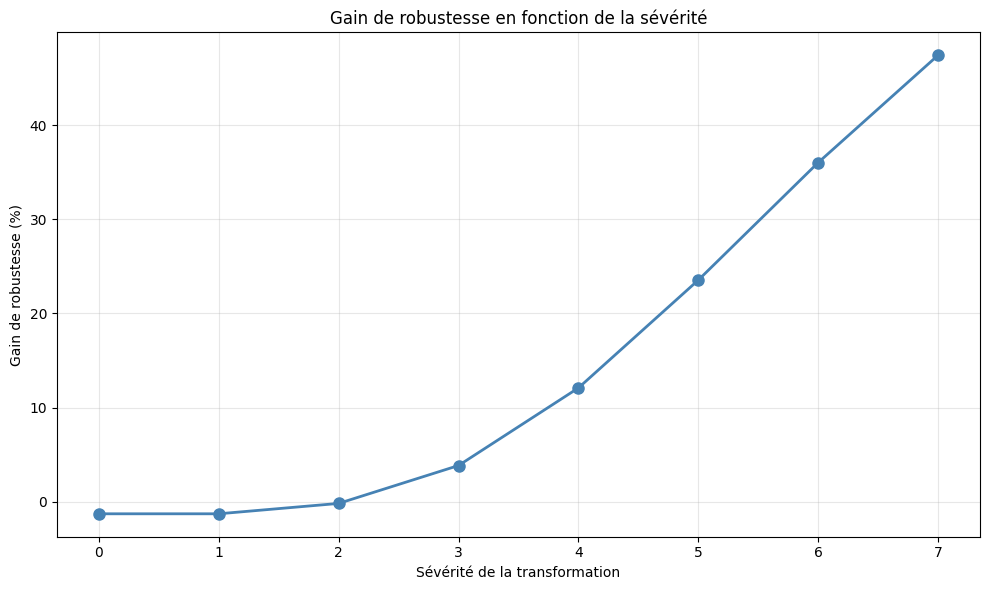

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(pivot.index, pivot["gain"], marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Sévérité de la transformation')
plt.ylabel('Gain de robustesse (%)')
plt.title('Gain de robustesse en fonction de la sévérité')
plt.grid(True, alpha=0.3)
plt.xticks(pivot.index)
plt.tight_layout()
plt.show()

In [16]:
auc_df = (
    df_test_list.sort_values("severity")
      .groupby(["net_name", "seed", "data_augmentation"])
      .apply(
          lambda g: np.trapz(
              g["accuracy"],
              g["severity"]
          )
      )
      .reset_index(name="auc")
)

C:\Users\ludol\AppData\Local\Temp\ipykernel_1524\3002260308.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [17]:
auc_df

,net_name,seed,data_augmentation,auc
0,128-10,1,False,529.500
1,128-10,1,True,644.100
2,128-10,2,False,524.940
3,128-10,2,True,647.705
4,128-10,3,False,524.895
...,...,...,...,...
67,simplified_lenet5,1,True,675.395
68,simplified_lenet5,2,False,589.630
69,simplified_lenet5,2,True,674.795
70,simplified_lenet5,3,False,595.880


In [18]:
gain_df = (auc_df.pivot(index=["net_name", "seed"], columns="data_augmentation", values="auc"))

gain_df["gain_auc"] = (gain_df[True] - gain_df[False])

In [19]:
gain_df.head()

data_augmentation    False     True  gain_auc
net_name seed                                
128-10   1         529.500  644.100   114.600
         2         524.940  647.705   122.765
         3         524.895  644.235   119.340
400-10   1         532.160  667.280   135.120
         2         531.185  665.025   133.840

Les architectures bénéficient-elles différemment de la data augmentation en termes de robustesse ?

In [20]:
gain_df = gain_df.reset_index()
model = ols(
    "gain_auc ~ C(net_name)",
    data=gain_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                   sum_sq    df           F        PR(>F)
C(net_name)  19999.706364  11.0  123.017058  2.491076e-18
Residual       354.712783  24.0         NaN           NaN


In [21]:
gain_df.groupby("net_name")["gain_auc"].agg(["mean", "std"]).sort_values("mean", ascending=False)

,mean,std
net_name,,
400-300-10,147.083333,3.098808
400-10,135.983333,2.681349
128-10,118.901667,4.100111
dropout_simple_CNN,94.425000,7.578392
dilated_lenet5,93.996667,2.053931
lenet4,92.248333,5.671116
lenet5,91.135000,1.799090
CNN_with_BN,90.166667,2.223074
network3,81.846667,2.092309


In [22]:
auc_sans_df = auc_df[auc_df["data_augmentation"] == False]

In [23]:
auc_sans_df.head()

,net_name,seed,data_augmentation,auc
0,128-10,1,False,529.500
2,128-10,2,False,524.940
4,128-10,3,False,524.895
6,400-10,1,False,532.160
8,400-10,2,False,531.185


In [24]:
model = ols(
    "auc ~ C(net_name)",
    data=auc_sans_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                   sum_sq    df           F        PR(>F)
C(net_name)  33428.965631  11.0  253.603581  4.890167e-22
Residual       287.598167  24.0         NaN           NaN


Les modèles ont des robustesses intrinsèques significativement différentes.

In [25]:
auc_sans_df.groupby("net_name")["auc"].agg(["mean", "std"])

,mean,std
net_name,,
128-10,526.445000,2.645803
400-10,530.691667,1.767416
400-300-10,533.223333,3.663476
CNN_with_BN,599.440000,2.724651
dilated_lenet5,591.070000,1.611087
dropout_lenet5,614.651667,1.200774
dropout_simple_CNN,591.095000,6.595819
lenet1,603.068333,4.529190
lenet4,593.988333,4.678329


In [26]:
df_test_list_sans = df_test_list[df_test_list["data_augmentation"] == False].drop(["data_augmentation"], axis=1)

In [27]:
df_test_list_sans

,net_name,accuracy,seed,severity
0,network3,99.32,1,0
1,CNN_with_BN,99.38,1,0
2,dropout_simple_CNN,99.37,1,0
3,dropout_lenet5,99.19,1,0
4,lenet5,99.25,1,0
...,...,...,...,...
283,dilated_lenet5,49.76,3,7
284,lenet1,55.72,3,7
285,400-300-10,35.94,3,7
286,400-10,35.49,3,7


In [28]:
df_drop_sans = df_test_list_sans.pivot_table(
    index=['net_name', 'seed'],
    columns='severity',
    values='accuracy',
    aggfunc='first'
).reset_index()

df_drop_sans = df_drop_sans.rename(columns={0: 'accuracy(0)', 7: 'accuracy(7)'})

df_drop_sans = df_drop_sans[['net_name', 'seed', 'accuracy(0)', 'accuracy(7)']]
df_drop_sans.columns.name = None
df_drop_sans["drop"] = df_drop_sans["accuracy(0)"] - df_drop_sans["accuracy(7)"]

In [29]:
df_drop_sans.head()

,net_name,seed,accuracy(0),accuracy(7),drop
0,128-10,1,98.07,35.41,62.66
1,128-10,2,97.96,35.62,62.34
2,128-10,3,98.14,35.11,63.03
3,400-10,1,98.35,36.09,62.26
4,400-10,2,98.31,36.60,61.71


In [30]:
df_test_list_aug = df_test_list[df_test_list["data_augmentation"] == True].drop(["data_augmentation"], axis=1)
df_test_list_aug

,net_name,accuracy,seed,severity
288,network3,98.57,1,0
289,CNN_with_BN,98.95,1,0
290,dropout_simple_CNN,98.38,1,0
291,dropout_lenet5,97.98,1,0
292,lenet5,98.80,1,0
...,...,...,...,...
571,dilated_lenet5,97.22,3,7
572,lenet1,94.01,3,7
573,400-300-10,95.86,3,7
574,400-10,93.20,3,7


In [31]:
df_drop_aug = df_test_list_aug.pivot_table(
    index=['net_name', 'seed'],
    columns='severity',
    values='accuracy',
    aggfunc='first'
).reset_index()

df_drop_aug = df_drop_aug.rename(columns={0: 'accuracy(0)', 7: 'accuracy(7)'})

df_drop_aug = df_drop_aug[['net_name', 'seed', 'accuracy(0)', 'accuracy(7)']]
df_drop_aug.columns.name = None
df_drop_aug["drop"] = df_drop_aug["accuracy(0)"] - df_drop_aug["accuracy(7)"]

df_drop_aug.head()

,net_name,seed,accuracy(0),accuracy(7),drop
0,128-10,1,92.92,89.30,3.62
1,128-10,2,93.89,89.70,4.19
2,128-10,3,93.53,89.18,4.35
3,400-10,1,96.08,93.48,2.60
4,400-10,2,96.12,92.51,3.61


In [37]:
df_drop_sans_mean = df_drop_sans.groupby("net_name")["drop"].agg(["mean", "std"]).sort_values("mean", ascending=True)
df_drop_sans_mean

,mean,std
net_name,,
dropout_lenet5,42.576667,0.296704
lenet1,42.583333,1.163715
network3,46.156667,0.754476
lenet5,47.396667,0.366652
CNN_with_BN,47.420000,0.869540
simplified_lenet5,47.666667,1.145484
lenet4,48.070000,1.458115
dilated_lenet5,48.460000,0.381576
dropout_simple_CNN,49.770000,1.663160


In [38]:
gain_mean_df = gain_df.groupby("net_name")["gain_auc"].agg(["mean", "std"]).sort_values("mean", ascending=False)
gain_mean_df

,mean,std
net_name,,
400-300-10,147.083333,3.098808
400-10,135.983333,2.681349
128-10,118.901667,4.100111
dropout_simple_CNN,94.425000,7.578392
dilated_lenet5,93.996667,2.053931
lenet4,92.248333,5.671116
lenet5,91.135000,1.799090
CNN_with_BN,90.166667,2.223074
network3,81.846667,2.092309


In [39]:
df_drop_aug_mean = df_drop_aug.groupby("net_name")["drop"].agg(["mean", "std"]).sort_values("mean", ascending=True)
df_drop_aug_mean

,mean,std
net_name,,
lenet5,0.893333,0.192180
dilated_lenet5,1.073333,0.127017
dropout_lenet5,1.196667,0.090738
lenet4,1.233333,0.256970
CNN_with_BN,1.240000,0.174356
dropout_simple_CNN,1.273333,0.310054
network3,1.350000,0.236432
400-300-10,1.600000,0.111355
simplified_lenet5,2.540000,0.586600


In [46]:
df_drop_sans_mean["drop_loss"] = df_drop_sans_mean["mean"] - df_drop_aug_mean["mean"]

In [47]:
df_drop_sans_mean

,mean,std,drop_loss
net_name,,,
dropout_lenet5,42.576667,0.296704,41.380000
lenet1,42.583333,1.163715,39.986667
network3,46.156667,0.754476,44.806667
lenet5,47.396667,0.366652,46.503333
CNN_with_BN,47.420000,0.869540,46.180000
simplified_lenet5,47.666667,1.145484,45.126667
lenet4,48.070000,1.458115,46.836667
dilated_lenet5,48.460000,0.381576,47.386667
dropout_simple_CNN,49.770000,1.663160,48.496667


In [48]:
df_drop_sans_mean.sort_values("drop_loss", ascending=False)

,mean,std,drop_loss
net_name,,,
400-300-10,61.760000,0.772075,60.160000
400-10,62.223333,0.496017,59.106667
128-10,62.676667,0.345302,58.623333
dropout_simple_CNN,49.770000,1.663160,48.496667
dilated_lenet5,48.460000,0.381576,47.386667
lenet4,48.070000,1.458115,46.836667
lenet5,47.396667,0.366652,46.503333
CNN_with_BN,47.420000,0.869540,46.180000
simplified_lenet5,47.666667,1.145484,45.126667
